<a href="https://colab.research.google.com/github/rafidhadizuhair/Laporan-Data-Mining-Rafid-Hadi-Zuhair_241011401361/blob/main/Pertemuan_5_dan_Tugas_Latihan_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Akurasi: 0.9111

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



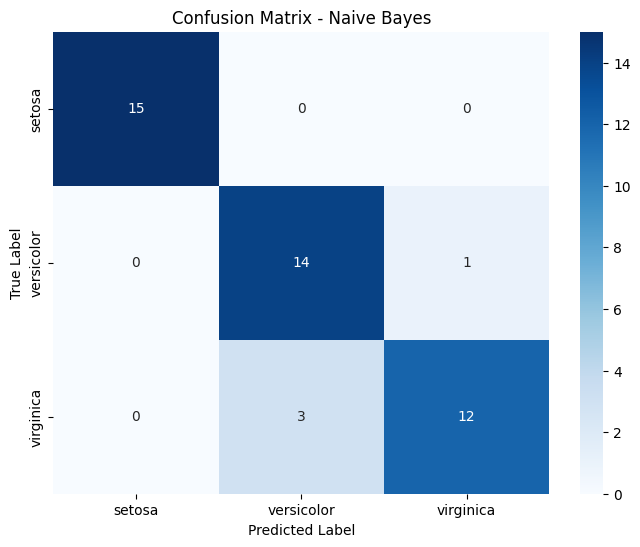


Probabilitas (Confidence Score) untuk 5 data pertama:
   setosa  versicolor  virginica
0     0.0      0.0000     1.0000
1     0.0      0.9955     0.0045
2     0.0      0.8472     0.1528
3     0.0      0.6680     0.3320
4     0.0      0.1036     0.8964


In [1]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_iris
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Split data (70% Train, 30% Test)
# Stratify memastikan proporsi kelas di data train dan test tetap seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Inisialisasi & Training Gaussian Naive Bayes
# Digunakan GaussianNB karena fitur pada dataset Iris adalah data numerik kontinu
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# 4. Prediksi
y_pred = gnb.predict(X_test)

# 5. Evaluasi Dasar
print(f"Akurasi: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 6. Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - Naive Bayes')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 7. Melihat Probabilitas Posterior
# Menampilkan peluang setiap kelas untuk 5 data pertama di test set
probabilities = gnb.predict_proba(X_test[:5])
print("\nProbabilitas (Confidence Score) untuk 5 data pertama:")
prob_df = pd.DataFrame(probabilities, columns=iris.target_names)
print(prob_df.round(4))

In [2]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# 1. Menyiapkan Dataset Sederhana
emails = [
    "Free money click here win prize",
    "Meeting schedule for tomorrow",
    "Win lottery prize money free",
    "Project deadline extension request",
    "Click link to claim your prize",
    "Quarterly report attachment",
    "Free gift card for you",
    "Team lunch tomorrow"
]

# 1 = Spam, 0 = Not Spam (Ham)
labels = [1, 0, 1, 0, 1, 0, 1, 0]

# 2. Split Data Manual (Training: 6 data pertama, Test: 2 data terakhir)
X_train, X_test = emails[:6], emails[6:]
y_train, y_test = labels[:6], labels[6:]

# 3. Membangun Pipeline
# Pipeline mempermudah proses transformasi teks dan klasifikasi dalam satu langkah
pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer()), # Mengubah teks menjadi angka (bobot TF-IDF)
    ('classifier', MultinomialNB())    # Algoritma Naive Bayes untuk data frekuensi/teks
])

# 4. Training Model
pipeline.fit(X_train, y_train)

# 5. Prediksi Data Test
y_pred = pipeline.predict(X_test)

# --- Output Hasil Prediksi ---
print("--- Hasil Prediksi Data Test ---")
for email, pred, actual in zip(X_test, y_pred, y_test):
    status = "SPAM" if pred == 1 else "NOT SPAM"
    actual_status = "SPAM" if actual == 1 else "NOT SPAM"
    print(f"Email    : '{email}'")
    print(f"Prediksi : {status} (Asli: {actual_status})")
    print("-" * 30)

# 6. Analisis Fitur (Feature Importance)
# Mencari kata-kata yang paling kuat mengindikasikan email tersebut SPAM
vectorizer = pipeline.named_steps['vectorizer']
classifier = pipeline.named_steps['classifier']
feature_names = vectorizer.get_feature_names_out()

# Mengambil probabilitas log dan mengubahnya kembali ke probabilitas biasa (exp)
spam_log_prob = classifier.feature_log_prob_[1]
top_spam_idx = np.argsort(spam_log_prob)[-10:]

print("\nTop 10 Kata Indikator SPAM:")
for idx in top_spam_idx:
    word = feature_names[idx]
    prob = np.exp(spam_log_prob[idx])
    print(f"{word:12}: {prob:.4f}")

--- Hasil Prediksi Data Test ---
Email    : 'Free gift card for you'
Prediksi : SPAM (Asli: SPAM)
------------------------------
Email    : 'Team lunch tomorrow'
Prediksi : NOT SPAM (Asli: NOT SPAM)
------------------------------

Top 10 Kata Indikator SPAM:
to          : 0.0495
claim       : 0.0495
your        : 0.0495
here        : 0.0512
lottery     : 0.0528
click       : 0.0606
free        : 0.0633
money       : 0.0633
win         : 0.0633
prize       : 0.0693


In [3]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_wine

# 1. Load dataset
wine = load_wine()
X = wine.data
y = wine.target

# 2. Normalisasi (SANGAT PENTING untuk k-NN!)
# k-NN menghitung jarak, jika skala berbeda jauh, fitur besar akan mendominasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# 4. K-NN Dasar (k=5)
knn = KNeighborsClassifier(n_neighbors=5, weights='uniform')
knn.fit(X_train, y_train)

# Prediksi Awal
y_pred = knn.predict(X_test)
print(f"Akurasi Dasar (k=5): {accuracy_score(y_test, y_pred):.4f}")

# 5. Tuning Hyperparameter dengan GridSearchCV
# Mencari kombinasi k, bobot, dan metrik jarak terbaik
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5, # 5-Fold Cross Validation
    scoring='accuracy',
    n_jobs=-1 # Gunakan semua core CPU untuk mempercepat
)

grid_search.fit(X_train, y_train)

# 6. Evaluasi Model Terbaik
print(f"\nParameter Terbaik    : {grid_search.best_params_}")
print(f"Akurasi CV Terbaik   : {grid_search.best_score_:.4f}")

best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test)
print(f"Akurasi Test Set Akhir: {accuracy_score(y_test, y_pred_best):.4f}")

Akurasi Dasar (k=5): 0.9444

Parameter Terbaik    : {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Akurasi CV Terbaik   : 0.9753
Akurasi Test Set Akhir: 0.9815


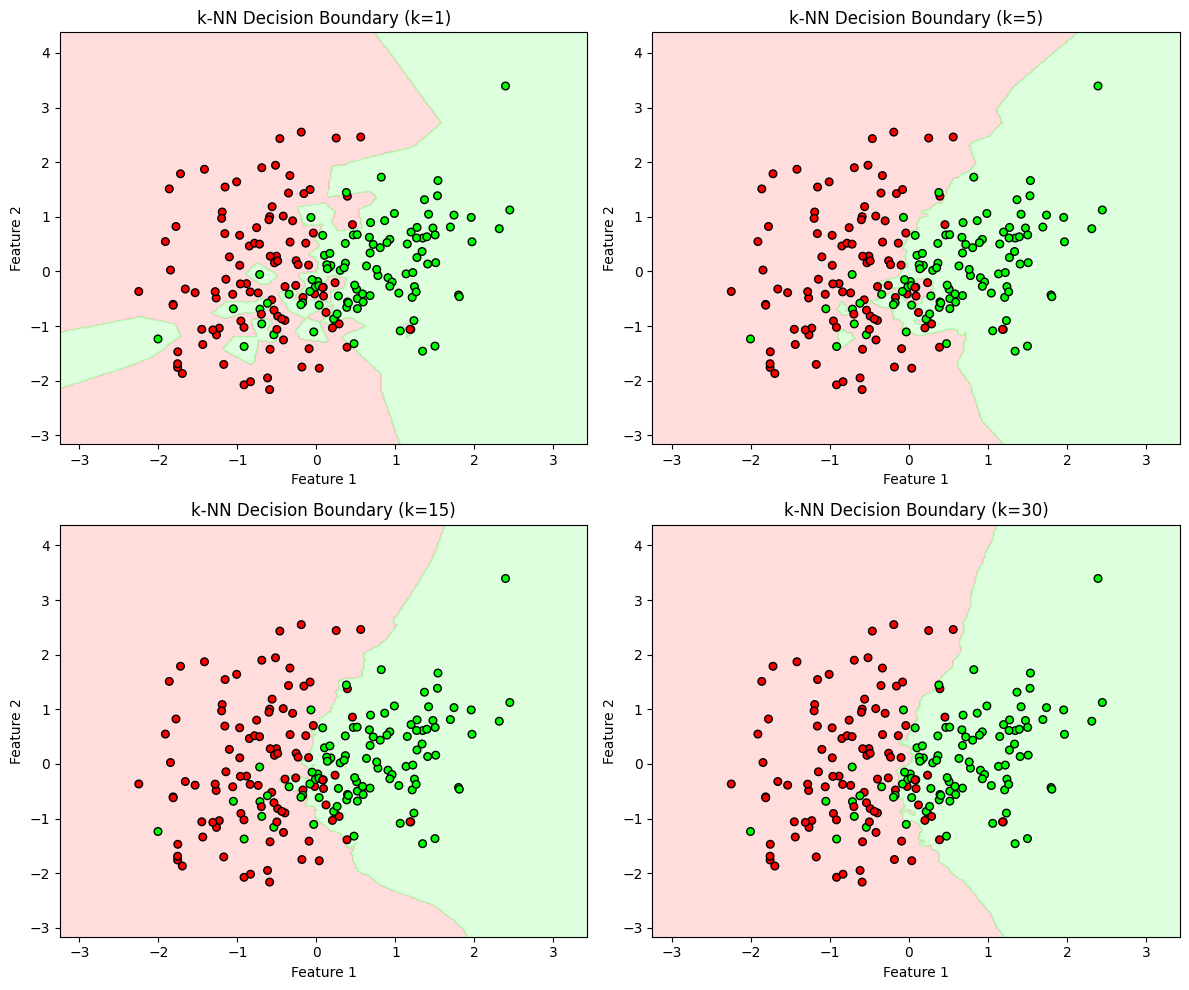

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap

# 1. Generate dataset 2D untuk visualisasi
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# 2. Normalisasi (Sangat disarankan untuk k-NN)
X = StandardScaler().fit_transform(X)

# 3. Pengaturan Visualisasi untuk berbagai nilai k
k_values = [1, 5, 15, 30]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

# Warna untuk plot (latar belakang dan titik data)
cmap_background = ListedColormap(['#FFAAAA', '#AAFFAA'])
cmap_points = ListedColormap(['#FF0000', '#00FF00'])

# 4. Loop untuk melatih model dan plotting
for idx, k in enumerate(k_values):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)

    # Membuat meshgrid untuk area plot
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Prediksi untuk setiap titik pada grid
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plotting Decision Boundary
    axes[idx].contourf(xx, yy, Z, alpha=0.4, cmap=cmap_background)

    # Plotting Titik Data Asli
    axes[idx].scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_points,
                      edgecolor='black', s=30)

    axes[idx].set_title(f'k-NN Decision Boundary (k={k})')
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Generate berbagai jenis dataset
datasets = {
    'Linear': make_classification(n_samples=500, n_features=10, n_informative=8, random_state=42),
    'Moons': make_moons(n_samples=500, noise=0.1, random_state=42),
    'Circles': make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)
}

# 2. Inisialisasi Model
models = {
    'Naive Bayes': GaussianNB(),
    'k-NN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'k-NN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'k-NN (k=15)': KNeighborsClassifier(n_neighbors=15)
}

# 3. Bandingkan Performa dengan Cross-Validation
results = []

for dataset_name, (X, y) in datasets.items():
    # Normalisasi SANGAT PENTING untuk k-NN (berbasis jarak)
    X_scaled = StandardScaler().fit_transform(X)

    for model_name, model in models.items():
        # Memilih data yang tepat (NB secara teoritis tidak wajib normalisasi)
        X_use = X_scaled if 'k-NN' in model_name else X

        # Menggunakan 5-Fold Cross Validation
        scores = cross_val_score(model, X_use, y, cv=5, scoring='accuracy')

        results.append({
            'Dataset': dataset_name,
            'Model': model_name,
            'Mean Accuracy': scores.mean(),
            'Std': scores.std()
        })

# 4. Menampilkan Hasil dalam DataFrame
results_df = pd.DataFrame(results)

# Membuat Pivot Table agar perbandingan lebih mudah dibaca
pivot = results_df.pivot(index='Dataset', columns='Model', values='Mean Accuracy')

print("--- Perbandingan Akurasi Rata-rata ---")
print(pivot.round(4))

--- Perbandingan Akurasi Rata-rata ---
Model    Naive Bayes  k-NN (k=15)  k-NN (k=3)  k-NN (k=7)
Dataset                                                  
Circles         1.00         1.00       1.000       1.000
Linear          0.73         0.88       0.894       0.886
Moons           0.87         1.00       1.000       1.000


In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# 1. Load Data (Asumsi data sudah dalam format DataFrame)
# Untuk latihan, kita buat simulasi struktur data PIMA
np.random.seed(42)
data_size = 768
data = {
    'Pregnancies': np.random.randint(0, 15, data_size),
    'Glucose': np.random.normal(120, 30, data_size),
    'BloodPressure': np.random.normal(70, 10, data_size),
    'BMI': np.random.normal(32, 5, data_size),
    'Age': np.random.randint(21, 80, data_size),
    'Outcome': np.random.randint(0, 2, data_size) # 0: Sehat, 1: Diabetes
}
df = pd.DataFrame(data)

# 2. Preprocessing
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# k-NN SANGAT butuh scaling, NB tidak wajib tapi aman dilakukan
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Training & Evaluasi
models = {
    "Gaussian Naive Bayes": GaussianNB(),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

print("--- HASIL DIAGNOSA ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")

--- HASIL DIAGNOSA ---
Gaussian Naive Bayes Accuracy: 0.5260
k-NN (k=5) Accuracy: 0.5195


In [8]:
from sklearn.neighbors import NearestNeighbors
import pandas as pd

# Contoh: Baris = User, Kolom = Produk (Rating 1-5, 0 = belum beli)
data = {
    'Laptop': [5, 4, 1, 0],
    'Mouse':  [5, 0, 0, 2],
    'Buku':   [1, 1, 5, 4],
    'Kopi':   [2, 2, 4, 5]
}
df = pd.DataFrame(data, index=['User_1', 'User_2', 'User_3', 'User_4'])

# Menggunakan Cosine Similarity untuk k-NN Rekomendasi
model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn.fit(df.values)

# Mencari 2 tetangga terdekat untuk User_1
distances, indices = model_knn.kneighbors(df.iloc[0, :].values.reshape(1, -1), n_neighbors=3)

print("Tetangga terdekat User_1:")
for i in range(1, len(distances.flatten())):
    print(f"{i}. {df.index[indices.flatten()[i]]} (Jarak: {distances.flatten()[i]:.4f})")

Tetangga terdekat User_1:
1. User_2 (Jarak: 0.2644)
2. User_4 (Jarak: 0.5176)
